# PCA on Olivetti Faces Dataset using Eigenvalue Decomposition

This notebook demonstrates how Principal Component Analysis (PCA) can be implemented **from scratch** using **Eigenvalue Decomposition** on the Olivetti Faces dataset.

Topics covered:
- Loading the dataset
- Visualizing faces
- Mean centering
- Covariance matrix computation
- Eigenvalue decomposition
- Selecting principal components
- Reconstructing images
- Visualizing eigenfaces


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces

plt.rcParams["figure.figsize"] = (8,6)
np.random.seed(42)


c:\Users\sride\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


## Load the Olivetti Faces Dataset

The dataset contains:
- 400 grayscale face images
- Each image size: 64 × 64
- Flattened size: 4096 features


In [2]:
# Load dataset
faces = fetch_olivetti_faces()

X = faces.data          # Shape: (400, 4096)
images = faces.images   # Shape: (400, 64, 64)

print("Data shape:", X.shape)
print("Image shape:", images.shape)


Data shape: (400, 4096)
Image shape: (400, 64, 64)


## Visualize Sample Faces

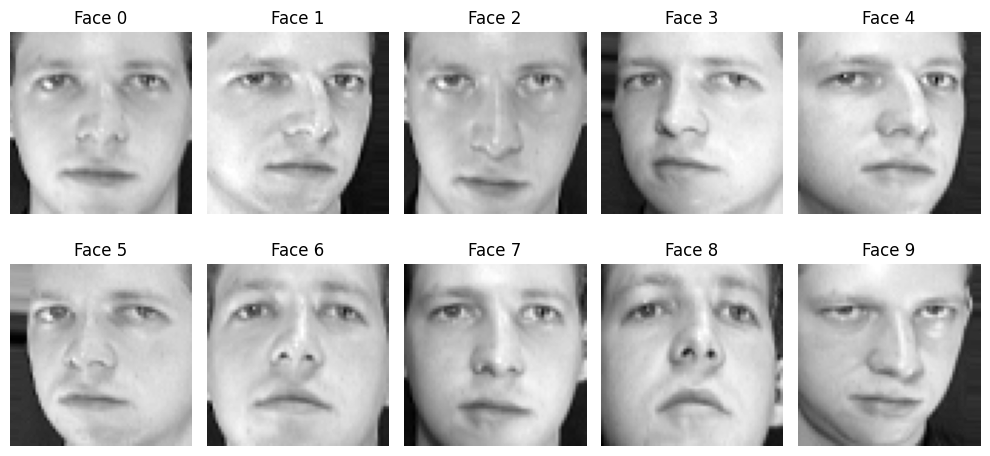

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f"Face {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 1: Mean Centering

PCA requires the data to be centered around zero.


In [4]:
# Compute mean face
mean_face = np.mean(X, axis=0)

# Center the data
X_centered = X - mean_face

print("Centered data shape:", X_centered.shape)


Centered data shape: (400, 4096)


## Visualize Mean Face

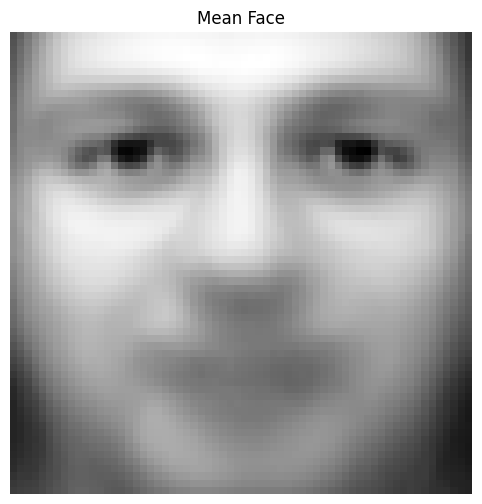

In [5]:
plt.imshow(mean_face.reshape(64,64), cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()


## Step 2: Covariance Matrix

Covariance matrix captures how features vary together.


In [6]:
# Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)


Covariance matrix shape: (4096, 4096)


## Step 3: Eigenvalue Decomposition

We compute:
- Eigenvalues
- Eigenvectors

Eigenvectors become the principal components.


In [7]:
# Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)


Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


## Step 4: Sort Eigenvectors by Importance

Larger eigenvalues represent more important directions.


In [8]:
# Sort in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

print("Top 5 eigenvalues:")
print(eigenvalues[:5])


Top 5 eigenvalues:
[18.84017581 11.0717621   6.30461473  3.9545841   2.85604263]


## Step 5: Visualize Eigenfaces

Eigenvectors reshaped into image form are called **Eigenfaces**.


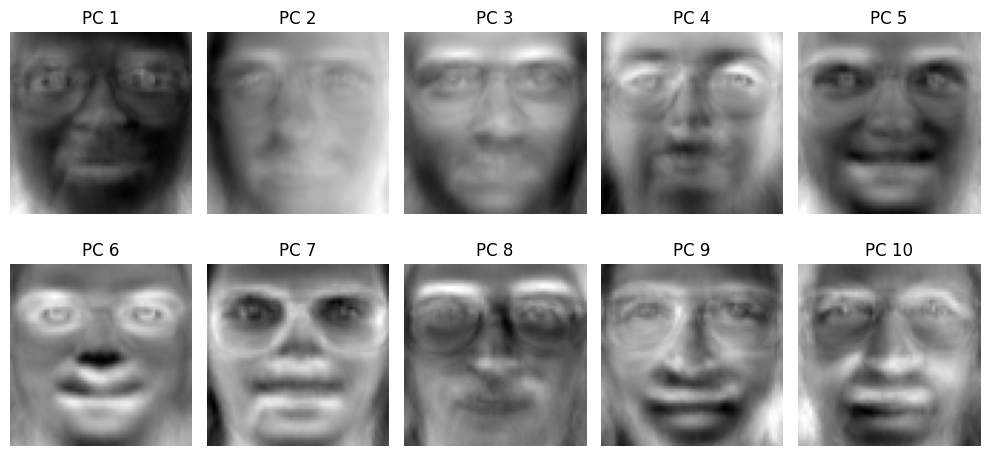

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    eigenface = eigenvectors[:, i].reshape(64,64)
    ax.imshow(eigenface, cmap='gray')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 6: Select Top Principal Components

In [10]:
k = 50

principal_components = eigenvectors[:, :k]

print("Principal components shape:", principal_components.shape)


Principal components shape: (4096, 50)


## Step 7: Transform Data into PCA Space

In [11]:
X_pca = np.dot(X_centered, principal_components)

print("Reduced data shape:", X_pca.shape)


Reduced data shape: (400, 50)


## Step 8: Reconstruct Images from PCA Representation

In [12]:
X_reconstructed = np.dot(X_pca, principal_components.T) + mean_face

print("Reconstructed data shape:", X_reconstructed.shape)


Reconstructed data shape: (400, 4096)


## Compare Original and Reconstructed Faces

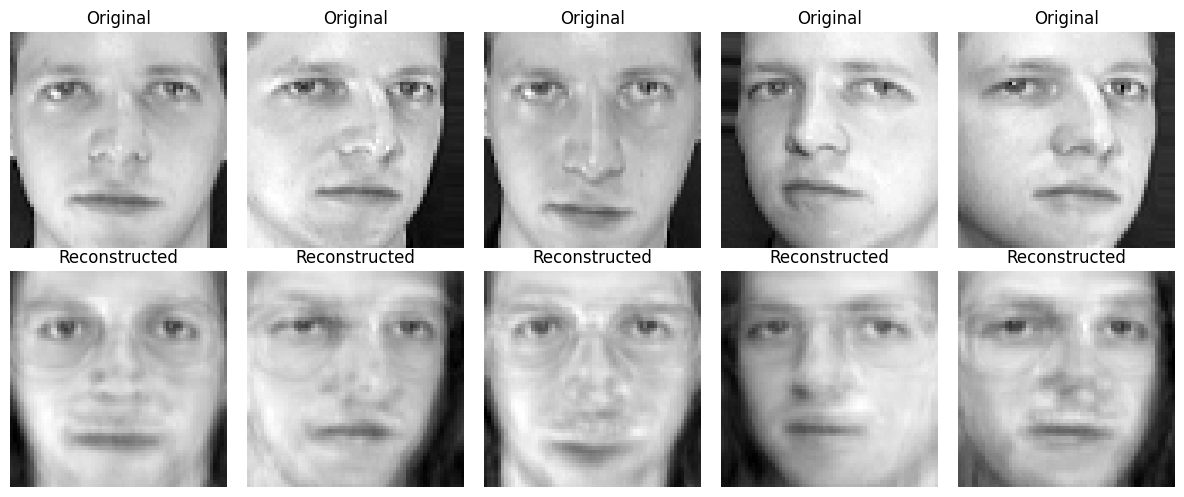

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i in range(5):
    # Original
    axes[0, i].imshow(X[i].reshape(64,64), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    # Reconstructed
    axes[1, i].imshow(X_reconstructed[i].reshape(64,64), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## Step 9: Explained Variance

Explained variance tells us how much information is preserved.


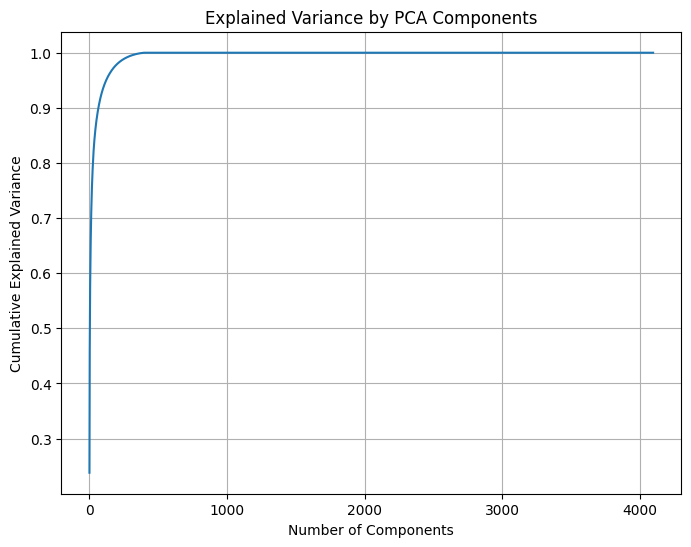

In [14]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)

plt.show()


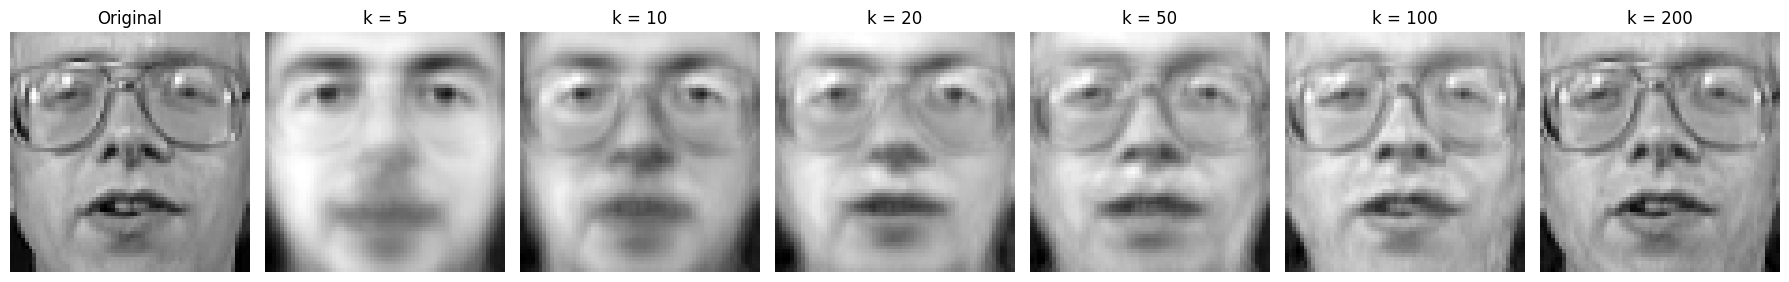

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select one face
face_index = 10

original_face = X[face_index]

# Different k values
k_values = [5, 10, 20, 50, 100, 200]

# Create figure
fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(18,4))

# Show original face
axes[0].imshow(original_face.reshape(64,64), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

# Mean-center the selected face
face_centered = original_face - mean_face

# Reconstruct for each k
for i, k in enumerate(k_values):
    # Select top-k eigenvectors
    principal_components = eigenvectors[:, :k]

    # Project into PCA space
    compressed = np.dot(face_centered, principal_components)

    # Reconstruct back to original space
    reconstructed = np.dot(compressed, principal_components.T)

    # Add mean back
    reconstructed = reconstructed + mean_face
    
    # Display image
    axes[i + 1].imshow(reconstructed.reshape(64,64), cmap='gray')
    axes[i + 1].set_title(f"k = {k}")
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

# Summary

In this notebook we:
1. Loaded the Olivetti Faces dataset
2. Mean-centered the data
3. Computed covariance matrix
4. Performed eigenvalue decomposition
5. Extracted principal components
6. Visualized eigenfaces
7. Reconstructed faces using reduced dimensions

This demonstrates how PCA compresses high-dimensional image data while preserving important information.
